1. Problem Context
2. Dataset Overview
3. Data Cleaning and Preparation
4. Exploratory Demand Analysis
5. Demand Variability and Seasonality
6. Inventory and Planning Insights
7. Conclusion


Problem Context

This project analyzes historical demand data to identify trends, variability, and seasonality patterns, with the objective of deriving insights relevant to inventory planning and demand forecasting in retail operations.

In [ ]:
import pandas as pd

df = pd.read_csv("/Walmart.csv")
df.head()


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [ ]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

The date column was converted to datetime format using day-first parsing to correctly handle the dataset’s date representation.

In [ ]:

df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

df.dtypes

store_df = df[df["Store"] == 1].copy()
store_df.shape
store_df[["Date", "Weekly_Sales"]].head()

,Date,Weekly_Sales
0,2010-02-05,1643690.90
1,2010-02-12,1641957.44
2,2010-02-19,1611968.17
3,2010-02-26,1409727.59
4,2010-03-05,1554806.68


In [ ]:
store_df = store_df.sort_values("Date")
store_df[["Date", "Weekly_Sales"]].head()


,Date,Weekly_Sales
0,2010-02-05,1643690.90
1,2010-02-12,1641957.44
2,2010-02-19,1611968.17
3,2010-02-26,1409727.59
4,2010-03-05,1554806.68


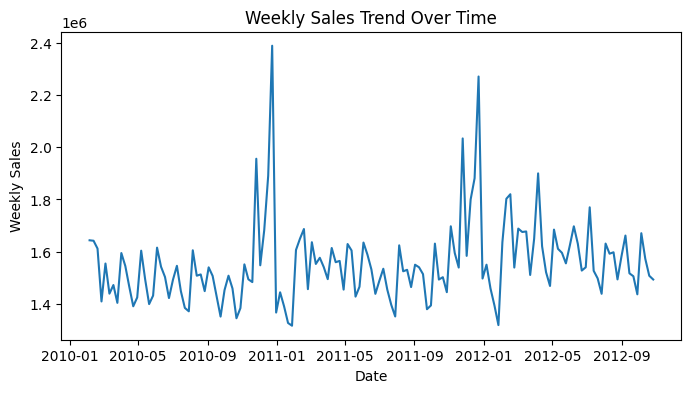

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(store_df["Date"], store_df["Weekly_Sales"])
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.title("Weekly Sales Trend Over Time")
plt.show()


In [ ]:
store_df["Rolling_Mean_4W"] = store_df["Weekly_Sales"].rolling(window=4).mean()


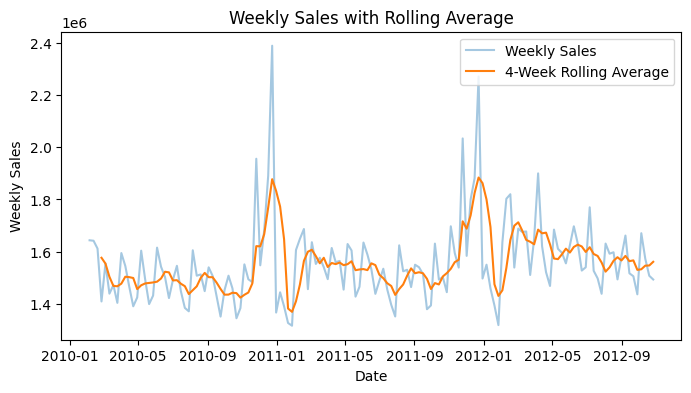

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(store_df["Date"], store_df["Weekly_Sales"], alpha=0.4, label="Weekly Sales")
plt.plot(store_df["Date"], store_df["Rolling_Mean_4W"], label="4-Week Rolling Average")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.title("Weekly Sales with Rolling Average")
plt.legend()
plt.show()


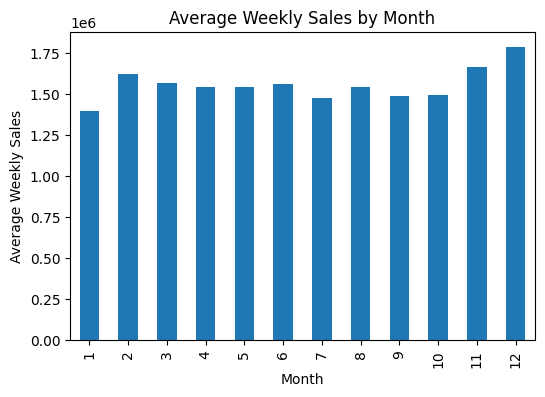

In [ ]:
store_df["Month"] = store_df["Date"].dt.month
monthly_avg = store_df.groupby("Month")["Weekly_Sales"].mean()

plt.figure(figsize=(6,4))
monthly_avg.plot(kind="bar")
plt.xlabel("Month")
plt.ylabel("Average Weekly Sales")
plt.title("Average Weekly Sales by Month")
plt.show()


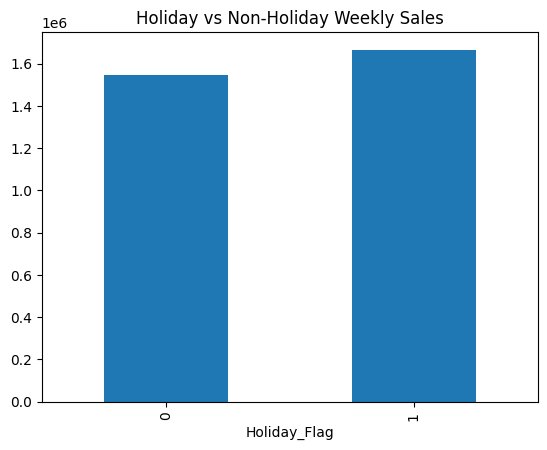

In [ ]:
holiday_avg = store_df.groupby("Holiday_Flag")["Weekly_Sales"].mean()
holiday_avg

holiday_avg.plot(kind="bar", title="Holiday vs Non-Holiday Weekly Sales")
plt.show()


In [ ]:
store_df["Weekly_Sales"].describe()


,Weekly_Sales
count,1.430000e+02
mean,1.555264e+06
std,1.559808e+05
min,1.316899e+06
25%,1.458105e+06
50%,1.534850e+06
75%,1.614892e+06
max,2.387950e+06


In [ ]:
mean_demand = store_df["Weekly_Sales"].mean()
std_demand = store_df["Weekly_Sales"].std()

mean_demand, std_demand


(np.float64(1555264.3975524476), 155980.76776119988)

In [ ]:
cv = std_demand / mean_demand
cv


np.float64(0.10029212268130751)

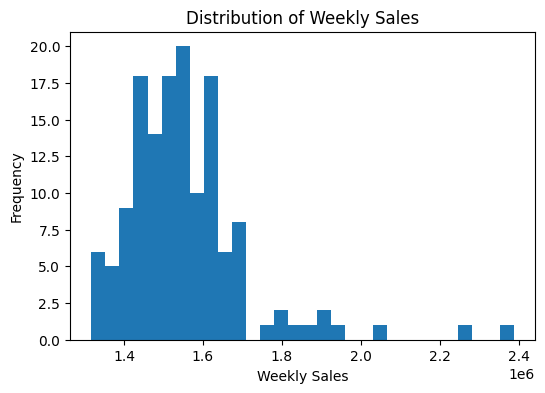

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(store_df["Weekly_Sales"], bins=30)
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")
plt.title("Distribution of Weekly Sales")
plt.show()


6. Inventory and Planning Insights

1. Trend Stability

Insight: Weekly demand shows short-term fluctuations but a relatively stable long-term trend when viewed using a rolling average.

Implication: Inventory planning should rely on smoothed demand trends rather than reacting to weekly fluctuations, to avoid overstocking or stockouts.

2. Seasonal Demand Pattern

Insight: Sales exhibit clear seasonal variation, with certain months consistently showing higher average demand.

Implication: Inventory levels should be increased ahead of high-demand months and reduced during low-demand periods to optimize holding costs.

3. Holiday Demand Impact

Insight: Holiday weeks experience higher average sales compared to non-holiday weeks.

Implication: Additional safety stock and advance replenishment are required before holiday periods to meet demand surges.

4. Demand Variability (CV-based)
(Use your CV result to choose the wording)

If CV < 0.2

Insight: Demand variability is low and relatively stable.

Implication: Inventory planning can follow regular replenishment cycles with minimal safety stock.

If 0.2–0.5 (most likely)

Insight: Demand shows moderate variability relative to its mean.

Implication: Safety stock is necessary to absorb fluctuations and maintain service levels.

If CV > 0.5

Insight: Demand variability is high and unpredictable.

Implication: Higher safety stock or more frequent replenishment is required to prevent stockouts.

5. Demand Distribution and Spikes

Insight: The demand distribution shows occasional high-demand weeks (outliers).

Implication: Inventory buffers must account for peak demand periods to avoid lost sales.

7. Conclusion

This analysis examined weekly sales data to identify demand trends, seasonality, and variability for a Walmart store. The results show that demand follows a stable long-term trend with seasonal and holiday-driven fluctuations. Moderate variability and occasional demand spikes highlight the need for safety stock and seasonal inventory planning. These insights can support data-driven decisions for inventory control and demand management.